## IMPORT LIBRARIES

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from sklearn.svm import SVC
import pickle
import joblib 
from joblib import Parallel, delayed
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


## LOAD AND EXPLORE DATA

#### Load dataset

In [28]:
data = pd.read_csv(r"C:\Users\Lenovo\Desktop\2ite3eme annee\NLP\NLP Project- Diabetes\diabetes_prediction_dataset.csv")

print("=== DATASET BASIC INFORMATION ===")
print(f"Dataset shape: {data.shape}")
print(f"Number of diabetic patients: {data['diabetes'].sum()}")
print(f"Diabetes prevalence: {(data['diabetes'].sum()/len(data))*100:.2f}%")


=== DATASET BASIC INFORMATION ===
Dataset shape: (100000, 9)
Number of diabetic patients: 8500
Diabetes prevalence: 8.50%


#### Display first few rows

In [29]:
print("\nFirst 5 rows:")
data.head()


First 5 rows:


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


#### DATA BASIC INFORMATION

In [30]:
print("=== DATASET INFO ===")
data.info()

=== DATASET INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


## DATA CLEANING AND PREPROCESSING

In [31]:
print("=== DATA CLEANING ===")

# Check for duplicates
print(f"Duplicate rows: {data.duplicated().sum()}")

# Remove duplicates
data = data.drop_duplicates()
print(f"Shape after removing duplicates: {data.shape}")

# Clean smoking_history categories
dict_map = {
    'No Info': 'No Information',
    'never': 'Never',
    'former': 'Not Current', 
    'current': 'Current',
    'not current': 'Not Current',
    'ever': 'Not Current'
}
data['smoking_history'] = data['smoking_history'].map(dict_map)

print("\nUpdated smoking history distribution:")
print(data['smoking_history'].value_counts())

print("\nGender distribution:")
print(data['gender'].value_counts())

=== DATA CLEANING ===
Duplicate rows: 3854
Shape after removing duplicates: (96146, 9)

Updated smoking history distribution:
smoking_history
Never             34398
No Information    32887
Not Current       19664
Current            9197
Name: count, dtype: int64

Gender distribution:
gender
Female    56161
Male      39967
Other        18
Name: count, dtype: int64


### HANDLE OUTLIERS

In [32]:
print("=== HANDLING OUTLIERS ===")

def handle_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    print(f"{column}: {len(outliers)} outliers found")
    
    # Cap outliers instead of removing
    df[column] = np.where(df[column] < lower_bound, lower_bound, df[column])
    df[column] = np.where(df[column] > upper_bound, upper_bound, df[column])
    
    return df

# Handle outliers for numerical columns
numerical_cols = ['age', 'bmi', 'HbA1c_level', 'blood_glucose_level']
for col in numerical_cols:
    data = handle_outliers(data, col)

print("Outliers handled successfully!")

=== HANDLING OUTLIERS ===
age: 0 outliers found
bmi: 5354 outliers found
HbA1c_level: 1312 outliers found
blood_glucose_level: 2031 outliers found
Outliers handled successfully!


## FEATURE ENGINEERING

In [33]:
print("=== FEATURE ENGINEERING ===")

# 1. Catégories BMI plus équilibrées selon l'OMS
data['bmi_category'] = pd.cut(data['bmi'], 
                             bins=[0, 18.5, 25, 30, 35, 40, float('inf')], 
                             labels=['Underweight', 'Normal', 'Overweight', 
                                    'Obese I', 'Obese II', 'Obese III'])

# 2. Groupes d'âge basés sur la distribution réelle des données
age_quantiles = data['age'].quantile([0.25, 0.5, 0.75]).values
data['age_group'] = pd.cut(data['age'], 
                          bins=[0, age_quantiles[0], age_quantiles[1], 
                               age_quantiles[2], 100],
                          labels=['Young', 'Adult', 'Middle-aged', 'Senior'])

# 3. Catégories HbA1c selon standards médicaux
data['HbA1c_category'] = pd.cut(data['HbA1c_level'],
                               bins=[0, 5.6, 6.4, 100],  # Standards médicaux
                               labels=['Normal', 'Prediabetes', 'Diabetes'])

# 4. Catégories glycémie selon standards médicaux
data['glucose_category'] = pd.cut(data['blood_glucose_level'],
                                 bins=[0, 99, 125, 200, 1000],  # Standards médicaux
                                 labels=['Normal', 'Prediabetes', 'Diabetes', 'Severe'])

# 5. Score de risque pondéré (amélioré)
data['risk_score'] = (data['age']/80 * 0.25 +           # Âge normalisé
                     (data['bmi']-15)/30 * 0.15 +       # BMI normalisé
                     data['HbA1c_level']/15 * 0.30 +    # HbA1c normalisé
                     data['blood_glucose_level']/300 * 0.20 +  # Glycémie normalisée
                     data['hypertension'] * 0.05 +      # Hypertension
                     data['heart_disease'] * 0.05)      # Maladie cardiaque

# 6. Nouvelles features interactives
data['age_bmi_interaction'] = data['age'] * data['bmi'] / 100
data['hba1c_glucose_ratio'] = data['HbA1c_level'] / (data['blood_glucose_level']/18 + 1e-6)

print("Nouvelles features créées:")
print(f"BMI Categories: {dict(data['bmi_category'].value_counts())}")
print(f"Age Groups: {dict(data['age_group'].value_counts())}")
print(f"Distribution du score de risque:")
print(data['risk_score'].describe())

=== FEATURE ENGINEERING ===
Nouvelles features créées:
BMI Categories: {'Overweight': 41871, 'Normal': 22280, 'Obese I': 12712, 'Obese II': 10765, 'Underweight': 8518, 'Obese III': 0}
Age Groups: {'Young': 24956, 'Adult': 24071, 'Senior': 23975, 'Middle-aged': 23144}
Distribution du score de risque:
count    96146.000000
mean         0.398853
std          0.104996
min          0.120967
25%          0.324817
50%          0.400558
75%          0.472267
max          0.782225
Name: risk_score, dtype: float64


### EXPLORATORY DATA ANALYSIS - TARGET VARIABLE

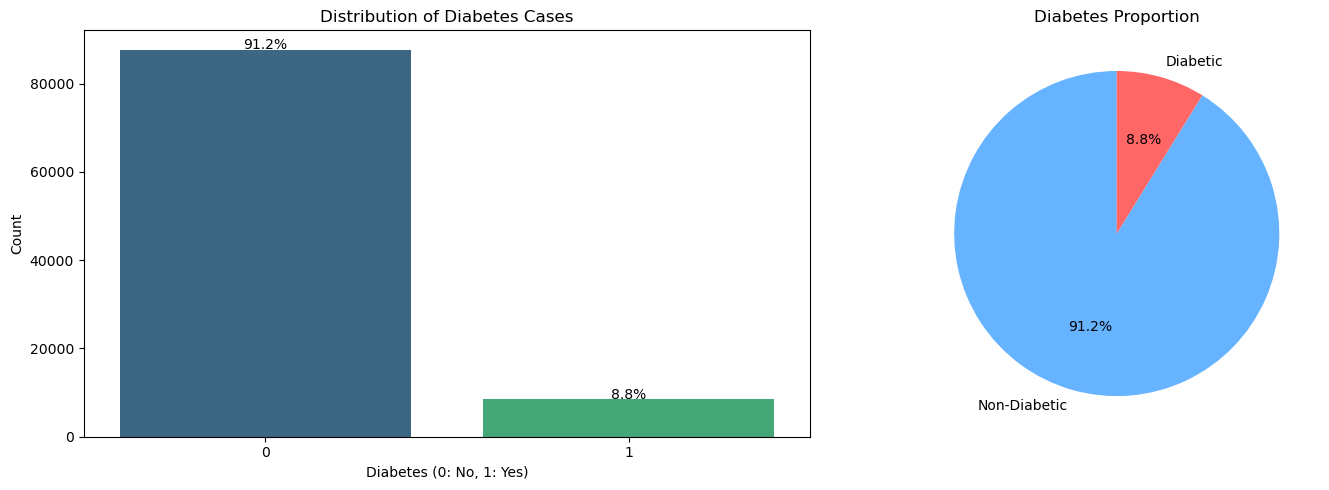

Diabetes prevalence: 8.82%


In [34]:
plt.figure(figsize=(15, 5))

# Subplot 1: Count plot
plt.subplot(1, 2, 1)
sns.countplot(x='diabetes', data=data, palette='viridis')
plt.title('Distribution of Diabetes Cases')
plt.xlabel('Diabetes (0: No, 1: Yes)')
plt.ylabel('Count')

# Add percentage annotations
total = len(data)
for p in plt.gca().patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height() + 100
    plt.gca().annotate(percentage, (x, y), ha='center')

# Subplot 2: Pie chart
plt.subplot(1, 2, 2)
diabetes_counts = data['diabetes'].value_counts()
colors = ['#66b3ff','#ff6666']
plt.pie(diabetes_counts, labels=['Non-Diabetic', 'Diabetic'], 
        autopct='%1.1f%%', startangle=90, colors=colors)
plt.title('Diabetes Proportion')

plt.tight_layout()
plt.show()

print(f"Diabetes prevalence: {data['diabetes'].mean()*100:.2f}%")

### EXPLORATORY DATA ANALYSIS - CATEGORICAL FEATURES

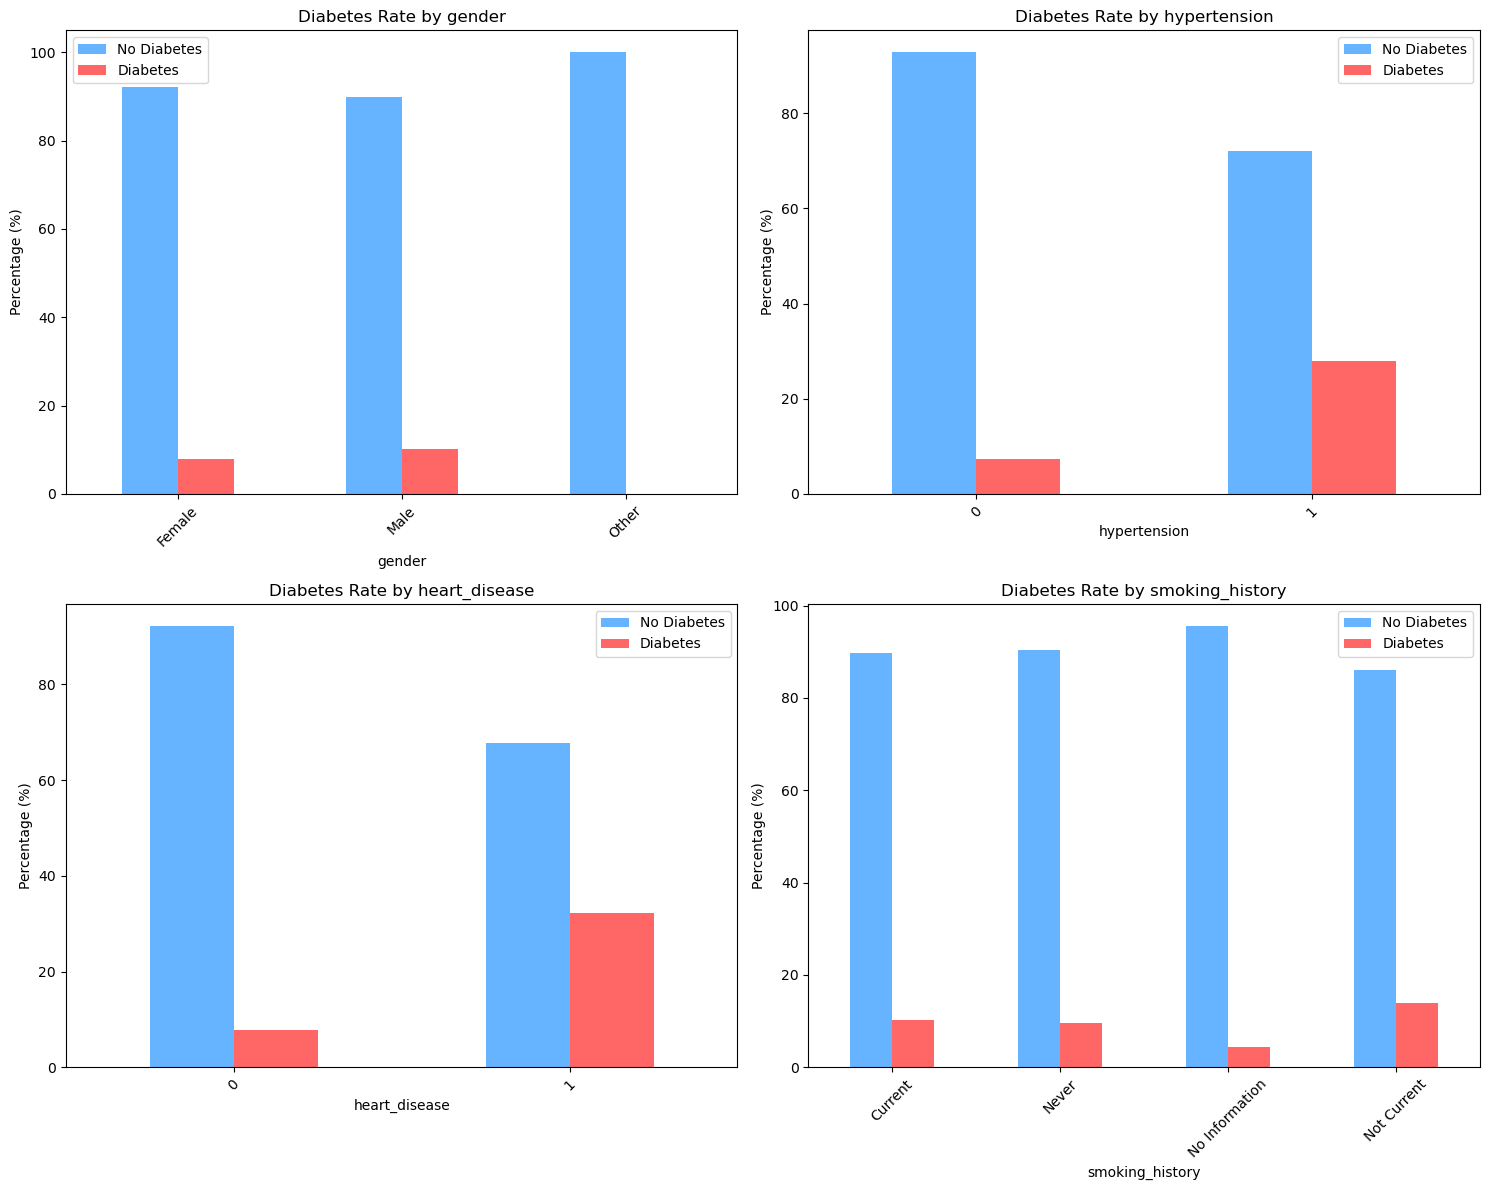

In [35]:
categorical_features = ['gender', 'hypertension', 'heart_disease', 'smoking_history']

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.ravel()

for i, feature in enumerate(categorical_features):
    # Calculate percentages
    cross_tab = pd.crosstab(data[feature], data['diabetes'], normalize='index') * 100
    
    # Plot
    cross_tab.plot(kind='bar', ax=axes[i], color=['#66b3ff','#ff6666'])
    axes[i].set_title(f'Diabetes Rate by {feature}')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Percentage (%)')
    axes[i].legend(['No Diabetes', 'Diabetes'])
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### EXPLORATORY DATA ANALYSIS - CORRELATION MATRIX

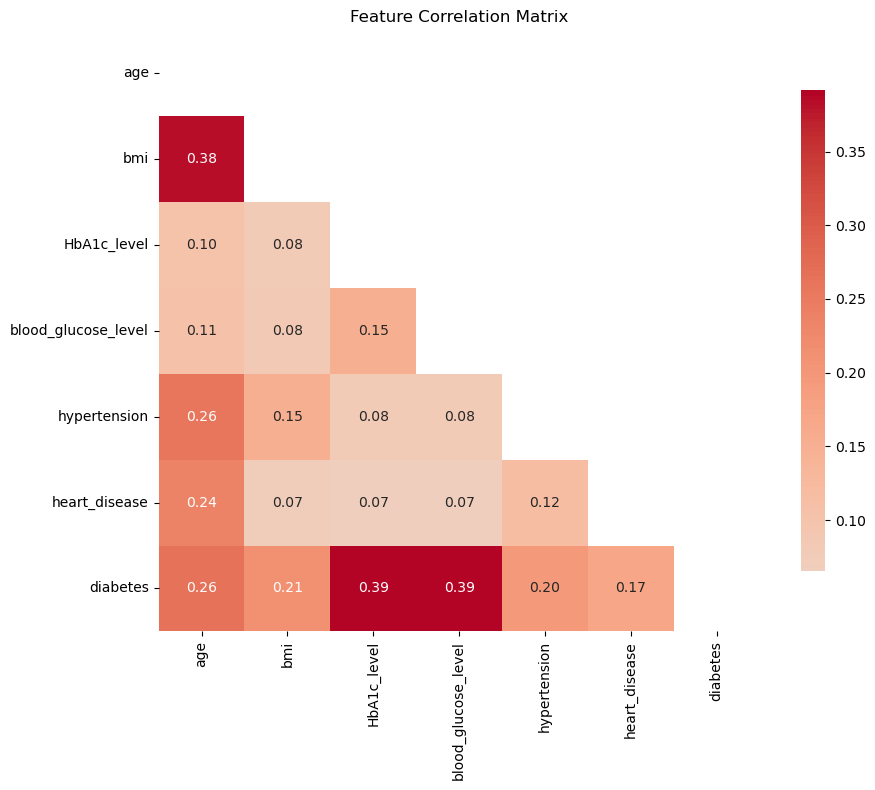

Top correlations with diabetes:
diabetes               1.000000
blood_glucose_level    0.391470
HbA1c_level            0.390543
age                    0.264927
bmi                    0.212017
hypertension           0.195710
heart_disease          0.170711
Name: diabetes, dtype: float64


In [36]:
# Select numerical features for correlation
numerical_data = data[['age', 'bmi', 'HbA1c_level', 'blood_glucose_level', 
                       'hypertension', 'heart_disease', 'diabetes']]

plt.figure(figsize=(10, 8))
correlation_matrix = numerical_data.corr()

# Create heatmap
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, fmt='.2f', mask=mask, cbar_kws={"shrink": .8})
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

print("Top correlations with diabetes:")
diabetes_corr = correlation_matrix['diabetes'].sort_values(ascending=False)
print(diabetes_corr)

### EXPLORATORY DATA ANALYSIS - NEW FEATURES

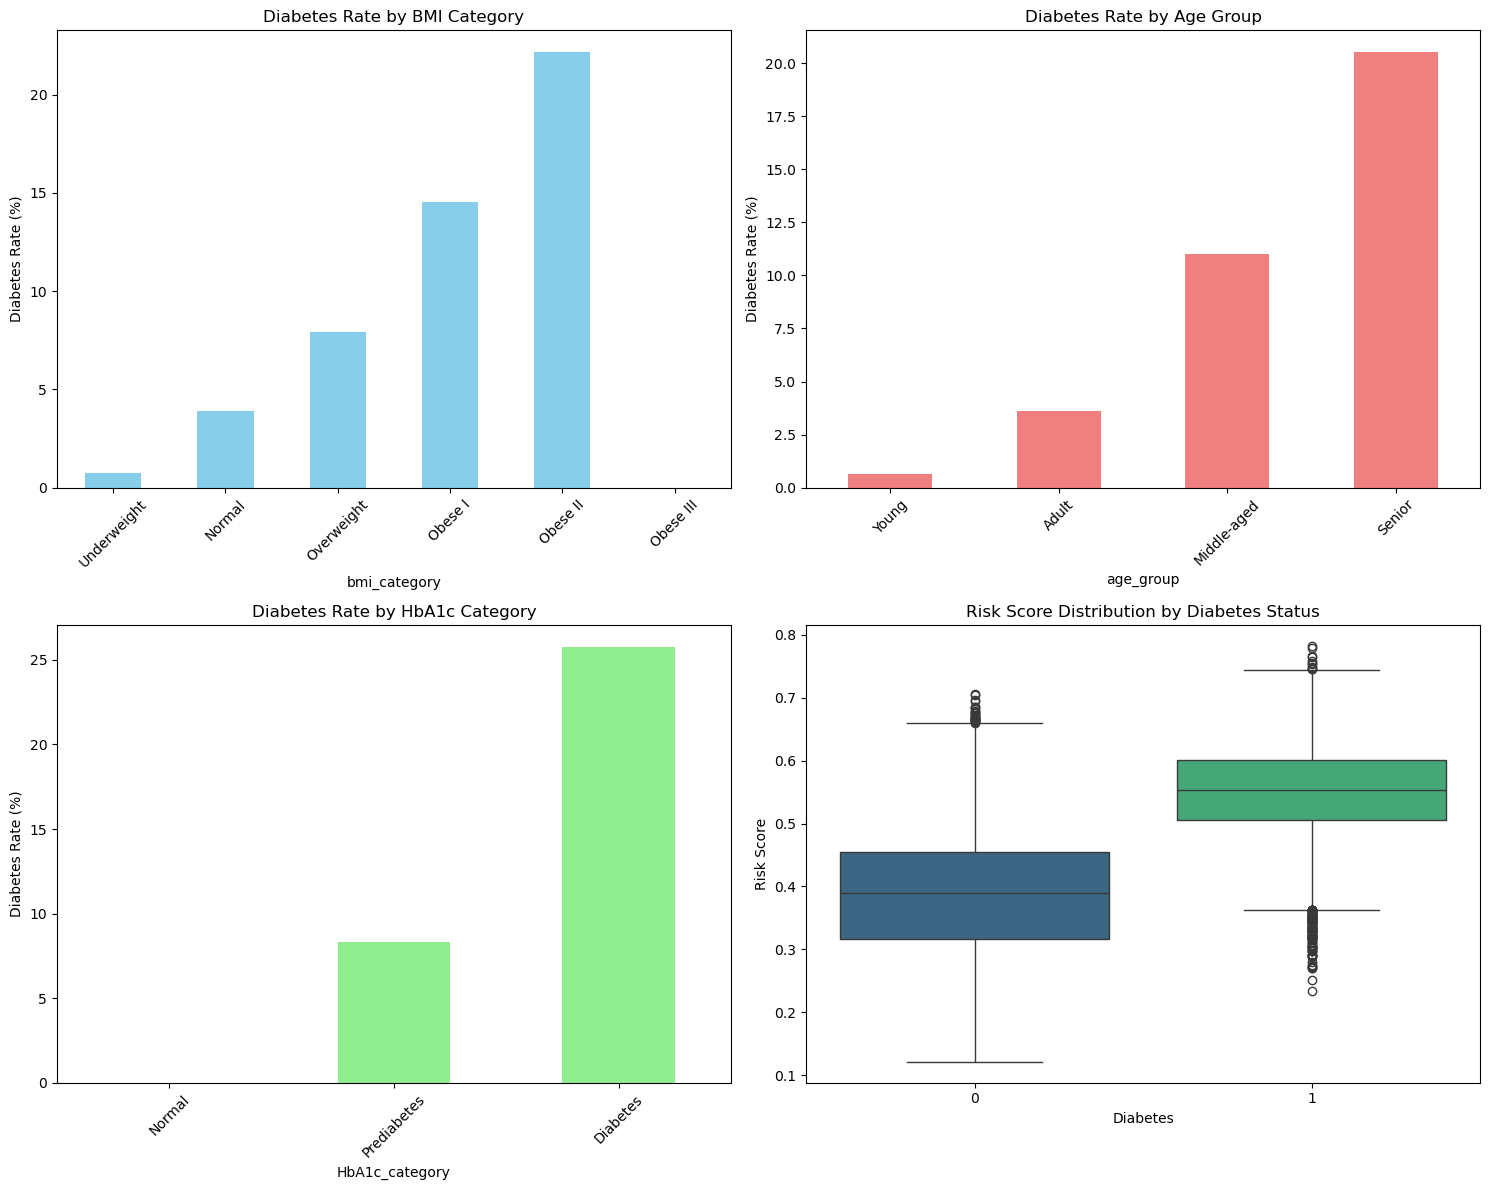

In [37]:
# Plot new engineered features
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# BMI Categories
bmi_diabetes = data.groupby('bmi_category')['diabetes'].mean() * 100
bmi_diabetes.plot(kind='bar', ax=axes[0,0], color='skyblue')
axes[0,0].set_title('Diabetes Rate by BMI Category')
axes[0,0].set_ylabel('Diabetes Rate (%)')
axes[0,0].tick_params(axis='x', rotation=45)

# Age Groups
age_diabetes = data.groupby('age_group')['diabetes'].mean() * 100
age_diabetes.plot(kind='bar', ax=axes[0,1], color='lightcoral')
axes[0,1].set_title('Diabetes Rate by Age Group')
axes[0,1].set_ylabel('Diabetes Rate (%)')
axes[0,1].tick_params(axis='x', rotation=45)

# HbA1c Categories
hba1c_diabetes = data.groupby('HbA1c_category')['diabetes'].mean() * 100
hba1c_diabetes.plot(kind='bar', ax=axes[1,0], color='lightgreen')
axes[1,0].set_title('Diabetes Rate by HbA1c Category')
axes[1,0].set_ylabel('Diabetes Rate (%)')
axes[1,0].tick_params(axis='x', rotation=45)

# Risk Score vs Diabetes
sns.boxplot(x='diabetes', y='risk_score', data=data, ax=axes[1,1], palette='viridis')
axes[1,1].set_title('Risk Score Distribution by Diabetes Status')
axes[1,1].set_xlabel('Diabetes')
axes[1,1].set_ylabel('Risk Score')

plt.tight_layout()
plt.show()

## DATA PREPARATION FOR MODELING

In [38]:
print("=== DATA PREPARATION ===")

# Create a copy for modeling
model_data = data.copy()

# One-hot encode categorical variables
categorical_columns = ['gender', 'smoking_history', 'bmi_category', 'age_group']
model_data = pd.get_dummies(model_data, columns=categorical_columns, drop_first=True)

# Drop original categorical columns and engineered categorical versions
columns_to_drop = ['HbA1c_category', 'glucose_category']
model_data = model_data.drop(columns=columns_to_drop, errors='ignore')

print(f"Shape after encoding: {model_data.shape}")
print(f"Columns: {list(model_data.columns)}")

=== DATA PREPARATION ===
Shape after encoding: (96146, 23)
Columns: ['age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes', 'risk_score', 'age_bmi_interaction', 'hba1c_glucose_ratio', 'gender_Male', 'gender_Other', 'smoking_history_Never', 'smoking_history_No Information', 'smoking_history_Not Current', 'bmi_category_Normal', 'bmi_category_Overweight', 'bmi_category_Obese I', 'bmi_category_Obese II', 'bmi_category_Obese III', 'age_group_Adult', 'age_group_Middle-aged', 'age_group_Senior']


## TRAIN-TEST SPLIT

#### Separate features and target

In [39]:
X = model_data.drop('diabetes', axis=1)
y = model_data['diabetes']

#### Split the data

In [40]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print("=== DATA SPLIT ===")
print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

=== DATA SPLIT ===
Training set shape: (67302, 22)
Testing set shape: (28844, 22)


## HANDLE CLASS IMBALANCE WITH SMOTE

In [41]:
print("=== HANDLING CLASS IMBALANCE ===")

print("Before SMOTE:")
print(f"Class distribution: {pd.Series(y_train).value_counts().to_dict()}")

# Apply SMOTE
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("\nAfter SMOTE:")
print(f"Class distribution: {pd.Series(y_train_resampled).value_counts().to_dict()}")
print(f"Resampled training set shape: {X_train_resampled.shape}")

=== HANDLING CLASS IMBALANCE ===
Before SMOTE:
Class distribution: {0: 61365, 1: 5937}

After SMOTE:
Class distribution: {0: 61365, 1: 61365}
Resampled training set shape: (122730, 22)


## FEATURE SCALING

In [42]:
# Initialize scaler
scaler = StandardScaler()

# Fit on training data and transform both training and testing data
X_train_scaled = scaler.fit_transform(X_train_resampled)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed!")
print(f"Scaled training set shape: {X_train_scaled.shape}")
print(f"Scaled testing set shape: {X_test_scaled.shape}")

Feature scaling completed!
Scaled training set shape: (122730, 22)
Scaled testing set shape: (28844, 22)


In [43]:
X_train_resampled.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 122730 entries, 0 to 122729
Data columns (total 22 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   age                             122730 non-null  float64
 1   hypertension                    122730 non-null  int64  
 2   heart_disease                   122730 non-null  int64  
 3   bmi                             122730 non-null  float64
 4   HbA1c_level                     122730 non-null  float64
 5   blood_glucose_level             122730 non-null  float64
 6   risk_score                      122730 non-null  float64
 7   age_bmi_interaction             122730 non-null  float64
 8   hba1c_glucose_ratio             122730 non-null  float64
 9   gender_Male                     122730 non-null  bool   
 10  gender_Other                    122730 non-null  bool   
 11  smoking_history_Never           122730 non-null  bool   
 12  smoking_history_

## MODEL TRAINING

In [44]:
# Initialize models
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss'),
    'SVM': SVC(random_state=42, probability=True)
}

# Train models
trained_models = {}
for name, model in models.items():
    print(f"Training {name}...")
    if name == 'SVM':
        # SVM works better with scaled data
        model.fit(X_train_scaled, y_train_resampled)
        trained_models[name] = model
    else:
        model.fit(X_train_resampled, y_train_resampled)
        trained_models[name] = model

print("All models trained successfully!")

Training Logistic Regression...
Training Decision Tree...
Training Random Forest...
Training XGBoost...
Training SVM...
All models trained successfully!


### MODEL EVALUATION

In [45]:
print("=== MODEL EVALUATION ===")

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Initialize dictionaries to store results
accuracy_scores = {}
precision_scores = {}
recall_scores = {}
f1_scores = {}
classification_reports = {}
confusion_matrices = {}

# Evaluate each model
for name, model in trained_models.items():
    if name == 'SVM':
        y_pred = model.predict(X_test_scaled)
        y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    else:
        y_pred = model.predict(X_test)
        y_pred_proba = model.predict_proba(X_test)[:, 1]
    
    # Calculate metrics
    accuracy_scores[name] = accuracy_score(y_test, y_pred)
    precision_scores[name] = precision_score(y_test, y_pred)
    recall_scores[name] = recall_score(y_test, y_pred)
    f1_scores[name] = f1_score(y_test, y_pred)
    
    # Store reports
    classification_reports[name] = classification_report(y_test, y_pred)
    confusion_matrices[name] = confusion_matrix(y_test, y_pred)

# Display results
results_df = pd.DataFrame({
    'Accuracy': accuracy_scores,
    'Precision': precision_scores,
    'Recall': recall_scores,
    'F1-Score': f1_scores
}).sort_values('F1-Score', ascending=False)

print("Model Performance Comparison:")
print(results_df.round(4))

=== MODEL EVALUATION ===
Model Performance Comparison:
                     Accuracy  Precision  Recall  F1-Score
XGBoost                0.9666     0.8851  0.7143    0.7906
Random Forest          0.9575     0.7718  0.7363    0.7537
Decision Tree          0.9449     0.6702  0.7403    0.7035
SVM                    0.9302     0.5755  0.7953    0.6678
Logistic Regression    0.9050     0.4771  0.7965    0.5967


## CONFUSION MATRICES

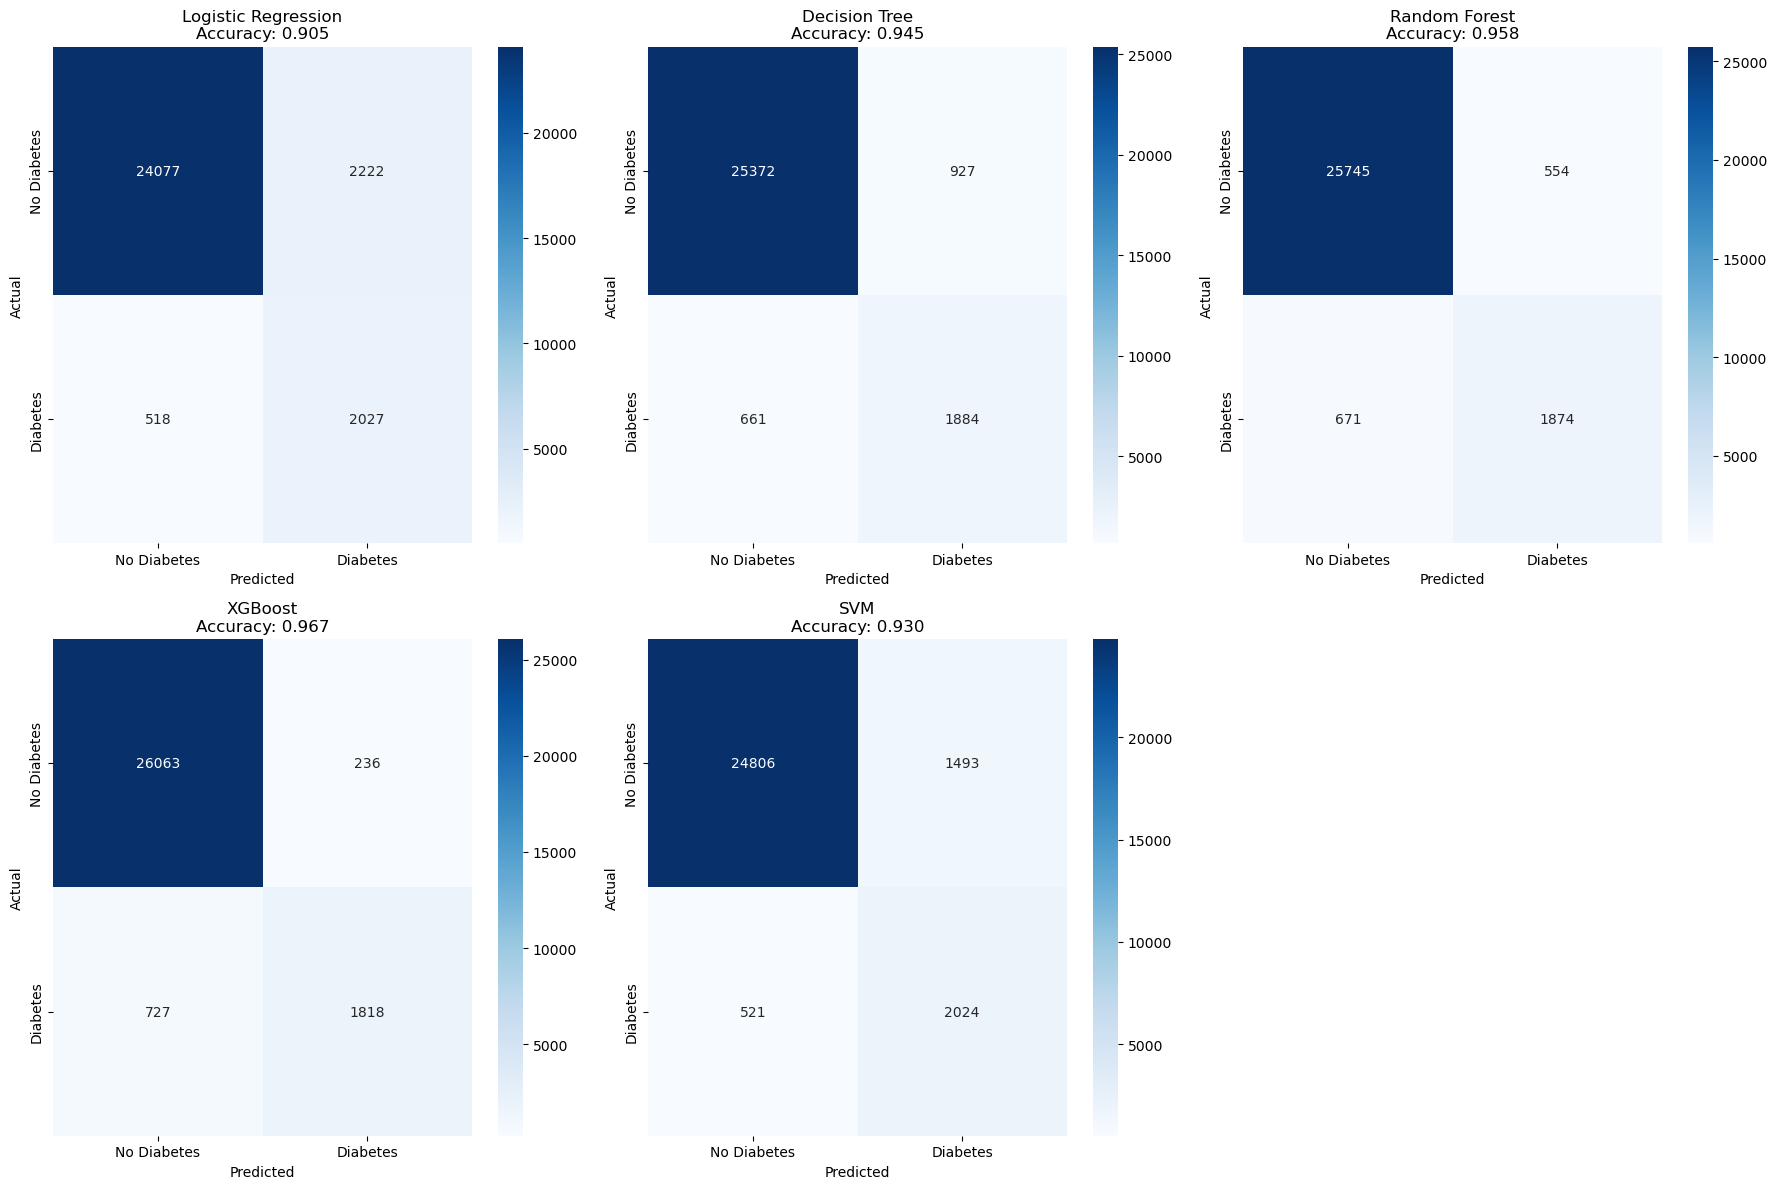

In [46]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.ravel()

# Plot confusion matrices for each model
for idx, (name, cm) in enumerate(confusion_matrices.items()):
    if idx < len(axes):
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                   xticklabels=['No Diabetes', 'Diabetes'],
                   yticklabels=['No Diabetes', 'Diabetes'])
        axes[idx].set_title(f'{name}\nAccuracy: {accuracy_scores[name]:.3f}')
        axes[idx].set_xlabel('Predicted')
        axes[idx].set_ylabel('Actual')

# Hide empty subplot
if len(confusion_matrices) < len(axes):
    for idx in range(len(confusion_matrices), len(axes)):
        axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

### PRECISION-RECALL CURVES

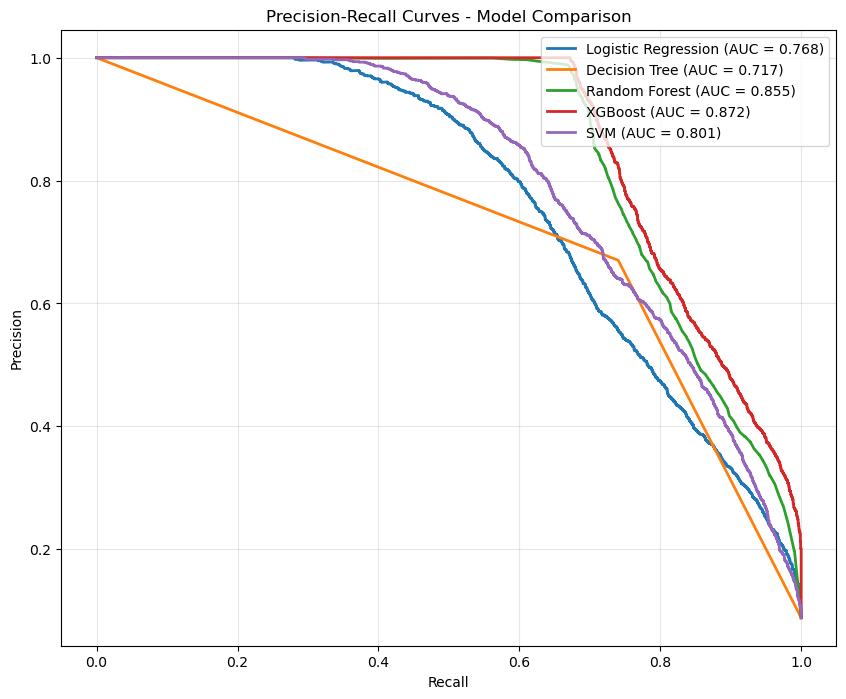

In [47]:
plt.figure(figsize=(10, 8))

for name, model in trained_models.items():
    if name == 'SVM':
        y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    else:
        y_pred_proba = model.predict_proba(X_test)[:, 1]
    
    precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
    pr_auc = auc(recall, precision)
    
    plt.plot(recall, precision, label=f'{name} (AUC = {pr_auc:.3f})', linewidth=2)

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves - Model Comparison')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.show()

## CROSS-VALIDATION

=== CROSS-VALIDATION ===
Logistic Regression: 0.726 (+/- 0.009)
Decision Tree: 0.723 (+/- 0.011)
Random Forest: 0.794 (+/- 0.017)
XGBoost: 0.803 (+/- 0.014)
SVM: 0.727 (+/- 0.014)


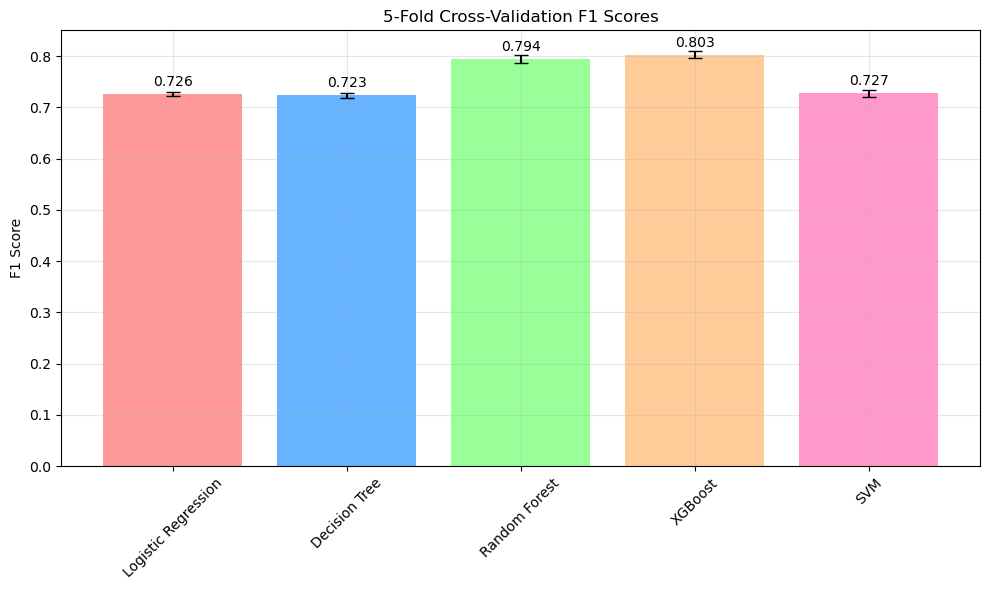

In [48]:
print("=== CROSS-VALIDATION ===")

# Perform 5-fold cross-validation
cv_results = {}
for name, model in models.items():
    if name == 'SVM':
        # Use scaled data for SVM
        cv_scores = cross_val_score(model, scaler.fit_transform(X), y, cv=5, scoring='f1')
    else:
        cv_scores = cross_val_score(model, X, y, cv=5, scoring='f1')
    
    cv_results[name] = cv_scores
    print(f"{name}: {cv_scores.mean():.3f} (+/- {cv_scores.std() * 2:.3f})")

# Plot cross-validation results
cv_means = [scores.mean() for scores in cv_results.values()]
cv_stds = [scores.std() for scores in cv_results.values()]
model_names = list(cv_results.keys())

plt.figure(figsize=(10, 6))
bars = plt.bar(model_names, cv_means, yerr=cv_stds, capsize=5, 
               color=['#ff9999', '#66b3ff', '#99ff99', '#ffcc99', '#ff99cc'])
plt.title('5-Fold Cross-Validation F1 Scores')
plt.ylabel('F1 Score')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

# Add value labels on bars
for bar, mean in zip(bars, cv_means):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{mean:.3f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

#### MODEL INTERPRETATION - FEATURE IMPORTANCE FOR BEST MODEL

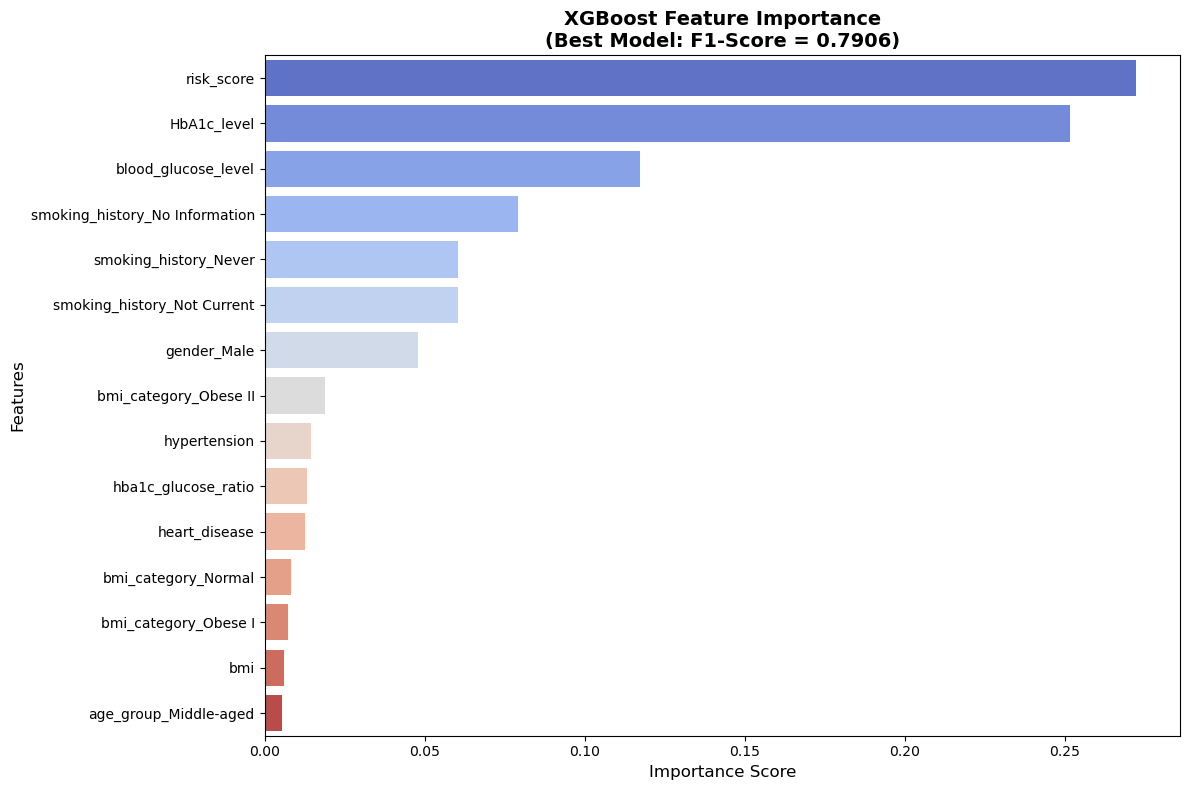

🎯 TOP 10 FEATURES PREDICTING DIABETES (XGBoost)
🏆 risk_score                     → Importance: 0.2724
🏆 HbA1c_level                    → Importance: 0.2515
🏆 blood_glucose_level            → Importance: 0.1172
🏆 smoking_history_No Information → Importance: 0.0792
🏆 smoking_history_Never          → Importance: 0.0605
🏆 smoking_history_Not Current    → Importance: 0.0605
🏆 gender_Male                    → Importance: 0.0478
🏆 bmi_category_Obese II          → Importance: 0.0190
🏆 hypertension                   → Importance: 0.0145
🏆 hba1c_glucose_ratio            → Importance: 0.0132


In [54]:
# SIMPLE SOLUTION - Using XGBoost from your results
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Since XGBoost was your best model (F1: 0.7906, Accuracy: 0.9666)
# Let's assume you have the model in 'trained_models'

# Get feature importance from XGBoost
xgb_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': trained_models['XGBoost'].feature_importances_
}).sort_values('importance', ascending=False)

# Create the plot
plt.figure(figsize=(12, 8))
sns.barplot(data=xgb_importance.head(15), x='importance', y='feature', 
            palette='coolwarm', hue='feature', legend=False)
plt.title('XGBoost Feature Importance\n(Best Model: F1-Score = 0.7906)', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.tight_layout()
plt.show()

# Display top features
print("🎯 TOP 10 FEATURES PREDICTING DIABETES (XGBoost)")
print("=" * 55)
top_10 = xgb_importance.head(10)
for i, row in top_10.iterrows():
    print(f"🏆 {row['feature']:30} → Importance: {row['importance']:.4f}")

### SAVE BEST MODEL AND PREPROCESSING OBJECTS

=== FINAL MODEL SUMMARY ===
Model Performance Comparison (XGBoost is Best Model):
                     Accuracy  Precision  Recall  F1-Score
XGBoost                0.9666     0.8851  0.7143    0.7906
Random Forest          0.9575     0.7718  0.7363    0.7537
Decision Tree          0.9449     0.6702  0.7403    0.7035
SVM                    0.9302     0.5755  0.7953    0.6678
Logistic Regression    0.9050     0.4771  0.7965    0.5967


<Figure size 1400x800 with 0 Axes>

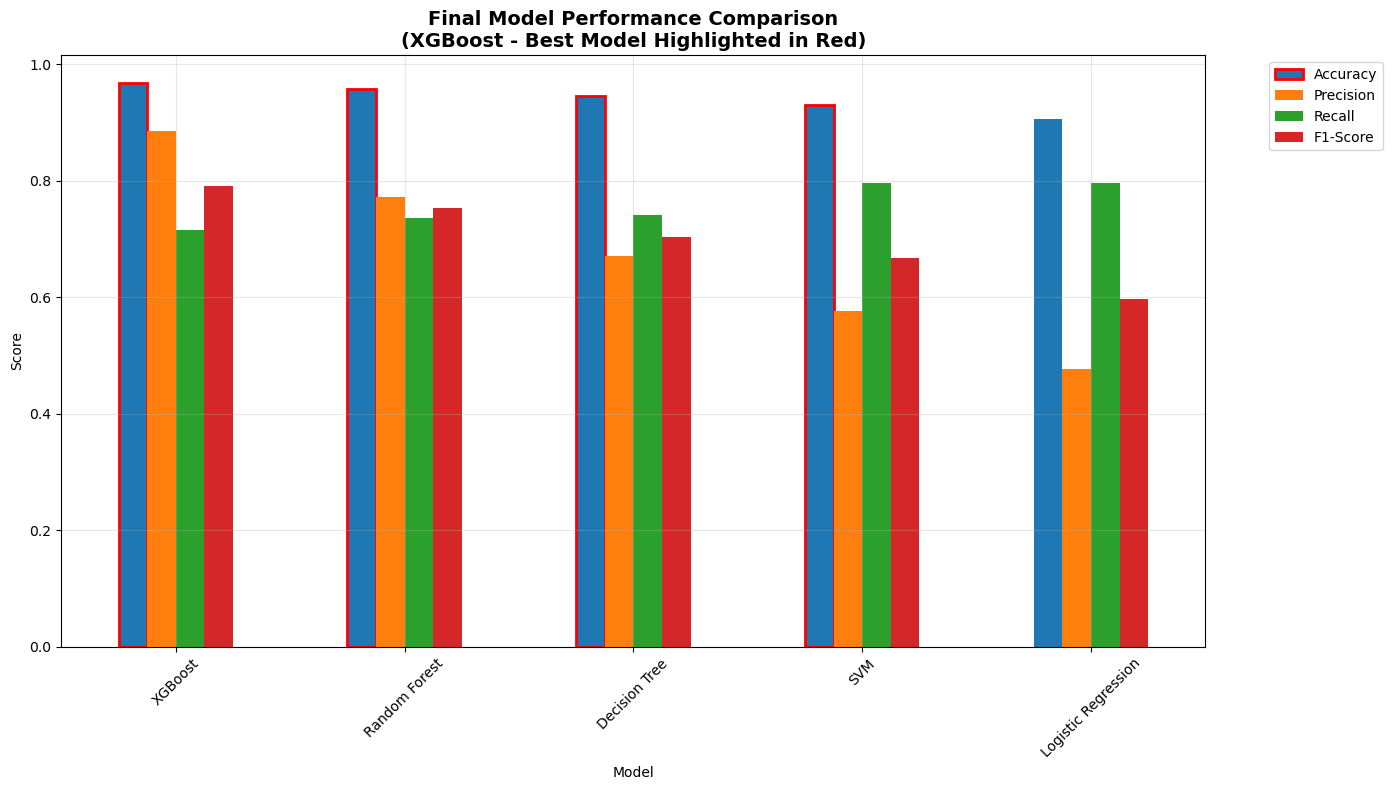


🎯 BEST MODEL: XGBoost
📊 F1-Score: 0.7906
🎯 Accuracy: 0.9666
🎯 Precision: 0.8851
🎯 Recall: 0.7143


In [56]:
print("=== FINAL MODEL SUMMARY ===")

# Create predictions with XGBoost (your best model)
y_pred_xgboost = trained_models['XGBoost'].predict(X_test)

# Create comprehensive comparison
final_comparison = results_df.copy()

# Add XGBoost performance to comparison (it should already be there, but we'll ensure it's highlighted)
print("Model Performance Comparison (XGBoost is Best Model):")
final_comparison = final_comparison.sort_values('F1-Score', ascending=False)
print(final_comparison.round(4))

# Highlight XGBoost in the plot
plt.figure(figsize=(14, 8))
ax = final_comparison[['Accuracy', 'Precision', 'Recall', 'F1-Score']].plot(kind='bar', figsize=(14, 8))

# Highlight XGBoost bar
n_models = len(final_comparison)
xgboost_index = list(final_comparison.index).index('XGBoost')
for i, bar in enumerate(ax.patches):
    if i // 4 == xgboost_index:  # 4 metrics per model
        bar.set_edgecolor('red')
        bar.set_linewidth(2)

plt.title('Final Model Performance Comparison\n(XGBoost - Best Model Highlighted in Red)', fontsize=14, fontweight='bold')
plt.ylabel('Score')
plt.xlabel('Model')
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n🎯 BEST MODEL: XGBoost")
print(f"📊 F1-Score: {final_comparison.loc['XGBoost']['F1-Score']:.4f}")
print(f"🎯 Accuracy: {final_comparison.loc['XGBoost']['Accuracy']:.4f}")
print(f"🎯 Precision: {final_comparison.loc['XGBoost']['Precision']:.4f}")
print(f"🎯 Recall: {final_comparison.loc['XGBoost']['Recall']:.4f}")

## FINAL MODEL SUMMARY

In [57]:
print("=== SAVING MODEL ===")

# Save the best model (XGBoost)
joblib.dump(trained_models['XGBoost'], 'best_diabetes_model_xgboost.pkl')

# Save the scaler
joblib.dump(scaler, 'scaler.pkl')

# Save feature names
with open('feature_names.pkl', 'wb') as f:
    pickle.dump(list(X.columns), f)

print("Model and preprocessing objects saved successfully!")
print("Files created:")
print("- best_diabetes_model_xgboost.pkl")
print("- scaler.pkl") 
print("- feature_names.pkl")

=== SAVING MODEL ===
Model and preprocessing objects saved successfully!
Files created:
- best_diabetes_model_xgboost.pkl
- scaler.pkl
- feature_names.pkl
